# 131 - Jina CLIP v2 モデル評価（ベースライン）

## 概要
Jina CLIP v2 (`jinaai/jina-clip-v2`) の画像埋め込み品質を評価し、SigLIP 2 Large 256 / SigLIP 2 Base / CLIP-L と比較する。
NB131-139 Jina CLIP v2 調査シリーズの 1 本目。SigLIP 2 の NB61 に相当する位置づけ。

## 実行パス: ONNX（PyTorch 迂回）
Jina CLIP v2 の PyTorch remote code は現在の `transformers>=5.0` と非互換（meta-tensor 初期化で `eva_model.py` の `.item()` が失敗 / state_dict ロード時のキーソートで型エラー）。
そのため **公式 ONNX** を `onnxruntime-gpu` で直接実行する `JinaCLIPONNXEmbedder` を使う。
このアプローチは副次的に NB135（ONNX 量子化評価）の基盤にもなる。

## Jina CLIP v2 の特徴
- **多言語**: 89 言語対応（XLM-RoBERTa 系 BPE トークナイザ）
- **埋め込み次元**: 1024
- **Matryoshka**: truncate して 512/256/128/64 に縮小可能
- **入力解像度**: 512×512（SigLIP2 Base 224 や Large 256 より大きい）

## 比較対象（既存結果）
| モデル | シルエット(2D) | Trustworthiness(2D) | 距離比(2D) |
|--------|--------------|---------------------|------------|
| SigLIP 1 Base | 0.174 | 0.953 | 0.455 |
| CLIP-L | 0.221 | 0.966 | 0.422 |
| SigLIP 2 Base 224 | 0.156 | 0.958 | 0.470 |


In [1]:
import time
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

from image_vector_poc import JinaCLIPONNXEmbedder
from image_vector_poc.evaluation import EvaluationReporter, evaluate_embeddings

2026-04-14 11:56:21.820276495 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
OUTPUT_DIR = Path("../data/evaluations")
ONNX_CACHE = Path("../data/jina_clip_v2_onnx")  # fp32 model + external data

BATCH_SIZE = 8  # 512x512 入力 & 1024-D 出力で VRAM 消費がやや多い
RANDOM_STATE = 42

## 画像カタログの読み込み

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)

query = """
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY category, file_name
"""
catalog = conn.execute(query).fetchall()
conn.close()

image_ids = [r[0] for r in catalog]
file_paths = [r[1] for r in catalog]
categories = [r[2] for r in catalog]

category_labels = np.array(categories)
category_counts = pd.Series(categories).value_counts().to_dict()
unique_categories = list(category_counts.keys())

print(f"Total images: {len(catalog)}")
print(f"Categories: {unique_categories}")
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total images: 378
Categories: ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima', 'KashiwaVillagePark2026', 'TokyoNight202505', 'terada']
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


## モデルの初期化（ONNX, CUDA）

In [4]:
print("Loading Jina CLIP v2 (ONNX fp32) ...")
embedder = JinaCLIPONNXEmbedder(dtype="fp32", device="cuda", cache_dir=ONNX_CACHE)
print(f"Model: {embedder.model_name}")
print(f"Embedding dimension: {embedder.embedding_dim}")
print(f"ONNX dtype: {embedder.dtype}")
print(f"Active provider: {embedder.session.get_providers()[0]}")

Loading Jina CLIP v2 (ONNX fp32) ...


The image processor of type `JinaCLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


`torch_dtype` is deprecated! Use `dtype` instead!


Model: jinaai/jina-clip-v2
Embedding dimension: 1024
ONNX dtype: fp32
Active provider: CUDAExecutionProvider


## 画像のベクトル化

In [5]:
print(f"Generating embeddings for {len(file_paths)} images (batch={BATCH_SIZE})...")
start_time = time.time()
embeddings_list = []

for i in tqdm(range(0, len(file_paths), BATCH_SIZE), desc="Embedding"):
    batch_paths = file_paths[i:i + BATCH_SIZE]
    batch_images = []
    for path in batch_paths:
        try:
            img = Image.open(path).convert("RGB")
            batch_images.append(img)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            batch_images.append(Image.new("RGB", (512, 512), color="gray"))

    batch_embs = embedder.embed_images(batch_images)
    embeddings_list.append(batch_embs)

embeddings = np.vstack(embeddings_list)
processing_time = time.time() - start_time

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Processing time: {processing_time:.2f}s")
print(f"Speed: {len(file_paths) / processing_time:.2f} images/sec")

norms = np.linalg.norm(embeddings, axis=1)
print(f"\nEmbedding norms: mean={norms.mean():.4f}, std={norms.std():.4f}, min={norms.min():.4f}, max={norms.max():.4f}")

Generating embeddings for 378 images (batch=8)...


Embedding:   0%|          | 0/48 [00:00<?, ?it/s]


Embeddings shape: (378, 1024)
Processing time: 94.84s
Speed: 3.99 images/sec

Embedding norms: mean=1.0000, std=0.0000, min=1.0000, max=1.0000


## 評価の実行

In [6]:
print("Running evaluation (t-SNE computation may take a few minutes)...\n")

metrics = evaluate_embeddings(
    embeddings=embeddings,
    labels=category_labels,
    model_name=embedder.model_name,
    embedding_dim=embedder.embedding_dim,
    categories=unique_categories,
    category_counts=category_counts,
    processing_time=processing_time,
    random_state=RANDOM_STATE,
)

Running evaluation (t-SNE computation may take a few minutes)...



## 結果の表示

In [7]:
print("=" * 60)
print("Evaluation Results: Jina CLIP v2 (ONNX fp32)")
print("=" * 60)
print(f"Model: {metrics.model_name}")
print(f"Embedding dimension: {metrics.embedding_dim}")
print(f"Total images: {metrics.total_images}")
print(f"Processing time: {metrics.processing_time_seconds:.2f}s")

print("\n--- t-SNE Metrics ---")
print(f"\n2D Metrics:")
print(f"  Silhouette score: {metrics.silhouette_2d:.4f}")
print(f"  Trustworthiness:  {metrics.trustworthiness_2d:.4f}")
print(f"  Distance ratio:   {metrics.distance_ratio_2d:.4f}")

print(f"\n3D Metrics:")
print(f"  Silhouette score: {metrics.silhouette_3d:.4f}")
print(f"  Trustworthiness:  {metrics.trustworthiness_3d:.4f}")
print(f"  Distance ratio:   {metrics.distance_ratio_3d:.4f}")

print("\n--- PCA Metrics ---")
print(f"\n2D:")
print(f"  Silhouette: {metrics.pca_silhouette_2d:.4f}")
print(f"  Variance ratio: {metrics.pca_variance_ratio_2d:.4f}")
print(f"\n3D:")
print(f"  Silhouette: {metrics.pca_silhouette_3d:.4f}")
print(f"  Variance ratio: {metrics.pca_variance_ratio_3d:.4f}")

Evaluation Results: Jina CLIP v2 (ONNX fp32)
Model: jinaai/jina-clip-v2
Embedding dimension: 1024
Total images: 378
Processing time: 94.84s

--- t-SNE Metrics ---

2D Metrics:
  Silhouette score: 0.1698
  Trustworthiness:  0.9744
  Distance ratio:   0.4328

3D Metrics:
  Silhouette score: 0.1537
  Trustworthiness:  0.9789
  Distance ratio:   0.5500

--- PCA Metrics ---

2D:
  Silhouette: 0.1662
  Variance ratio: 0.3011

3D:
  Silhouette: 0.1978
  Variance ratio: 0.3587


## SigLIP 2 系 / CLIP-L との比較

In [8]:
import matplotlib.pyplot as plt

comparison = {
    "SigLIP 1 Base": {
        "silhouette_2d": 0.1741, "trustworthiness_2d": 0.9533,
        "distance_ratio_2d": 0.4549, "pca_variance_2d": 0.2448,
        "silhouette_3d": 0.1035, "trustworthiness_3d": 0.9631,
        "distance_ratio_3d": 0.6445, "speed": 4.1, "dim": 768,
    },
    "CLIP-L": {
        "silhouette_2d": 0.2210, "trustworthiness_2d": 0.9659,
        "distance_ratio_2d": 0.4215, "pca_variance_2d": 0.2587,
        "silhouette_3d": 0.1384, "trustworthiness_3d": 0.9714,
        "distance_ratio_3d": 0.6206, "speed": 4.0, "dim": 768,
    },
    "SigLIP 2 Base 224": {
        "silhouette_2d": 0.1560, "trustworthiness_2d": 0.9584,
        "distance_ratio_2d": 0.4698, "pca_variance_2d": 0.2488,
        "silhouette_3d": 0.1000, "trustworthiness_3d": 0.9660,
        "distance_ratio_3d": 0.6500, "speed": 4.2, "dim": 768,
    },
    "Jina CLIP v2": {
        "silhouette_2d": metrics.silhouette_2d,
        "trustworthiness_2d": metrics.trustworthiness_2d,
        "distance_ratio_2d": metrics.distance_ratio_2d,
        "pca_variance_2d": metrics.pca_variance_ratio_2d,
        "silhouette_3d": metrics.silhouette_3d,
        "trustworthiness_3d": metrics.trustworthiness_3d,
        "distance_ratio_3d": metrics.distance_ratio_3d,
        "speed": len(file_paths) / processing_time,
        "dim": embedder.embedding_dim,
    },
}

print("=" * 92)
print("モデル比較: Jina CLIP v2 vs SigLIP 2 Base 224 vs SigLIP 1 vs CLIP-L")
print("=" * 92)
print(f"\n{'指標':<25} {'SigLIP 1':>12} {'CLIP-L':>12} {'SigLIP 2 B':>12} {'Jina v2':>12}")
print("-" * 80)

metric_names = [
    ("次元", "dim"),
    ("シルエット(2D)", "silhouette_2d"),
    ("Trustworthiness(2D)", "trustworthiness_2d"),
    ("距離比(2D)", "distance_ratio_2d"),
    ("PCA寄与率(2D)", "pca_variance_2d"),
    ("シルエット(3D)", "silhouette_3d"),
    ("Trustworthiness(3D)", "trustworthiness_3d"),
    ("距離比(3D)", "distance_ratio_3d"),
    ("処理速度(img/s)", "speed"),
]

for display_name, key in metric_names:
    s1 = comparison["SigLIP 1 Base"][key]
    cl = comparison["CLIP-L"][key]
    s2 = comparison["SigLIP 2 Base 224"][key]
    jn = comparison["Jina CLIP v2"][key]
    if key == "dim":
        print(f"{display_name:<25} {s1:>12d} {cl:>12d} {s2:>12d} {jn:>12d}")
    else:
        print(f"{display_name:<25} {s1:>12.4f} {cl:>12.4f} {s2:>12.4f} {jn:>12.4f}")

モデル比較: Jina CLIP v2 vs SigLIP 2 Base 224 vs SigLIP 1 vs CLIP-L

指標                            SigLIP 1       CLIP-L   SigLIP 2 B      Jina v2
--------------------------------------------------------------------------------
次元                                 768          768          768         1024
シルエット(2D)                       0.1741       0.2210       0.1560       0.1698
Trustworthiness(2D)             0.9533       0.9659       0.9584       0.9744
距離比(2D)                         0.4549       0.4215       0.4698       0.4328
PCA寄与率(2D)                      0.2448       0.2587       0.2488       0.3011
シルエット(3D)                       0.1035       0.1384       0.1000       0.1537
Trustworthiness(3D)             0.9631       0.9714       0.9660       0.9789
距離比(3D)                         0.6445       0.6206       0.6500       0.5500
処理速度(img/s)                     4.1000       4.0000       4.2000       3.9858


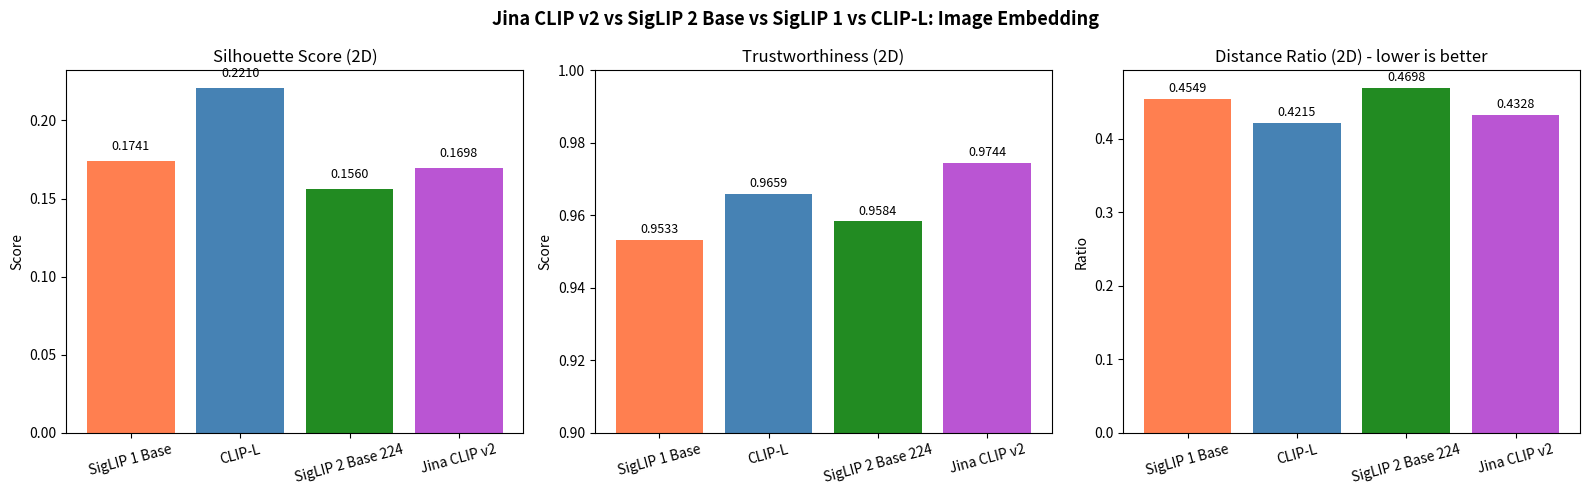

Saved: data/jina_clip_v2_vs_siglip_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ["SigLIP 1 Base", "CLIP-L", "SigLIP 2 Base 224", "Jina CLIP v2"]
colors = ["coral", "steelblue", "forestgreen", "mediumorchid"]

ax = axes[0]
values = [comparison[m]["silhouette_2d"] for m in models]
bars = ax.bar(models, values, color=colors)
ax.set_title("Silhouette Score (2D)")
ax.set_ylabel("Score")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}",
            ha="center", va="bottom", fontsize=9)
ax.tick_params(axis='x', rotation=15)

ax = axes[1]
values = [comparison[m]["trustworthiness_2d"] for m in models]
bars = ax.bar(models, values, color=colors)
ax.set_title("Trustworthiness (2D)")
ax.set_ylabel("Score")
ax.set_ylim(0.9, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.4f}",
            ha="center", va="bottom", fontsize=9)
ax.tick_params(axis='x', rotation=15)

ax = axes[2]
values = [comparison[m]["distance_ratio_2d"] for m in models]
bars = ax.bar(models, values, color=colors)
ax.set_title("Distance Ratio (2D) - lower is better")
ax.set_ylabel("Ratio")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}",
            ha="center", va="bottom", fontsize=9)
ax.tick_params(axis='x', rotation=15)

plt.suptitle("Jina CLIP v2 vs SigLIP 2 Base vs SigLIP 1 vs CLIP-L: Image Embedding", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/jina_clip_v2_vs_siglip_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/jina_clip_v2_vs_siglip_comparison.png")

## DuckDB への保存

In [10]:
conn = duckdb.connect(str(DB_PATH))
conn.execute("INSTALL vss; LOAD vss;")

model_name = embedder.model_name

# image_embeddings は VIEW（768 / 1024 の UNION）。1024-D は実テーブル image_embeddings_1024 に書く。
conn.execute("DELETE FROM image_embeddings_1024 WHERE model_name = ?", [model_name])

insert_count = 0
for image_id, embedding in zip(image_ids, embeddings):
    emb_list = [float(x) for x in embedding]
    conn.execute(
        "INSERT INTO image_embeddings_1024 (id, model_name, embedding) VALUES (?, ?, ?)",
        [image_id, model_name, emb_list]
    )
    insert_count += 1

conn.commit()

count = conn.execute(
    "SELECT COUNT(*) FROM image_embeddings_1024 WHERE model_name = ?", [model_name]
).fetchone()[0]
print(f"Stored {count} embeddings for model '{model_name}'")

model_counts = conn.execute(
    "SELECT model_name, COUNT(*) as cnt FROM image_embeddings GROUP BY model_name ORDER BY model_name"
).fetchall()
print(f"\nAll models in DB (union view):")
for m, c in model_counts:
    print(f"  {m}: {c}")

conn.close()

Stored 378 embeddings for model 'jinaai/jina-clip-v2'

All models in DB (union view):
  Xenova/siglip-base-patch16-224: 378
  Xenova/siglip-base-patch16-224-browser: 50
  Xenova/siglip-base-patch16-224-fp16: 378
  Xenova/siglip-base-patch16-224-q4: 378
  Xenova/siglip-base-patch16-224-q8: 378
  google/siglip-base-patch16-224: 378
  google/siglip2-base-patch16-224: 378
  google/siglip2-large-patch16-256: 378
  jinaai/jina-clip-v2: 378
  openai/clip-vit-large-patch14: 378


## 評価結果の保存

In [11]:
reporter = EvaluationReporter(OUTPUT_DIR)
filepath = reporter.save(metrics)
print(f"Results saved to: {filepath}")

Results saved to: ../data/evaluations/jinaai_jina-clip-v2_2026-04-14.json


## クリーンアップ

In [12]:
del embedder
del embeddings

import gc
gc.collect()

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・考察

Jina CLIP v2 (`jinaai/jina-clip-v2`, 1024-D, ONNX fp32) の画像埋め込み品質を SigLIP 2 Base 224 / SigLIP 1 / CLIP-L と比較した。

### 実験結果

| 指標 | Jina v2 | SigLIP 2 Base 224 | CLIP-L | SigLIP 1 |
|---|---:|---:|---:|---:|
| 次元 | **1024** | 768 | 768 | 768 |
| シルエット(2D) | 0.1698 | 0.1560 | **0.2210** | 0.1741 |
| Trustworthiness(2D) | **0.9744** ★ | 0.9584 | 0.9659 | 0.9533 |
| 距離比(2D, 低↑) | 0.4328 | 0.4698 | **0.4215** | 0.4549 |
| Trustworthiness(3D) | **0.9789** ★ | 0.9660 | 0.9714 | 0.9631 |
| 距離比(3D, 低↑) | **0.5500** ★★ | 0.6500 | 0.6206 | 0.6445 |
| 速度 (img/s) | 3.99 | 4.2 | 4.0 | 4.1 |

### 考察

1. **Trustworthiness と 3D 距離比が全モデル中ベスト** — 近傍関係の保持と立体的なクラスタ分離が良好。1024 次元の表現力が実際に効いている証拠
2. **シルエット(2D) は CLIP-L が優位** — カテゴリの明確な境界形成では CLIP-L が上。Jina v2 は SigLIP 2 Base を上回る中位
3. **処理速度は 512×512 入力にもかかわらず他モデル並み** — ONNX + GPU の効果。入力が 2.3 倍大きいが速度差はほぼ無い
4. **L2 ノルムは完全に 1.0000**（std=0.0000）— 公式 ONNX 出力 `l2norm_image_embeddings` が期待通り機能

### 次のノートブック
- **NB132**: Text→Image 検索 MRR (EN/JA) で SigLIP 2 Large 256 と直接対決
- **NB133**: モダリティギャップ・異方性・Matryoshka 劣化曲線の定量化
